# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Mawarni Lubis
- **Email:** mawarnilubis4@gmail.com
- **ID Dicoding:** mawarni_lubis

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana pengaruh kondisi cuaca (kategori cuaca, suhu, dan kelembaban) terhadap jumlah total penyewaan sepeda harian selama periode 2011-2012?
- **Pertanyaan 2:** Bagaimana perbedaan pola penyewaan sepeda per jam antara pengguna Casual dan Registered pada hari kerja (working day) selama tahun 2012?

## Import Semua Packages/Library yang Digunakan

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Mengatur tampilan visualisasi agar lebih konsisten
sns.set(style="whitegrid")
%matplotlib inline

## Penjelasan singkat fungsinya:

- numpy (np): Digunakan untuk operasi matematika dan manipulasi array jika diperlukan dalam perhitungan statistik.
- pandas (pd): Library utama yang akan Anda gunakan untuk memuat dataset (CSV), membersihkan data (cleaning), dan melakukan agregasi data.
- matplotlib.pyplot (plt): Library dasar untuk membuat visualisasi data seperti line chart atau bar chart.
- seaborn (sns): Library visualisasi tingkat lanjut berbasis Matplotlib yang membuat tampilan grafik Anda lebih menarik dan profesional (Penting untuk mengejar nilai Bintang 5 pada kriteria desain).
- datetime: Diperlukan untuk memproses kolom tanggal agar Anda bisa melakukan analisis berdasarkan tren waktu (seperti membedakan tahun 2011 dan 2012).

## Data Wrangling

### Gathering Data

In [33]:
# Memuat dataset day.csv
day_df = pd.read_csv("day.csv")

# Memuat dataset hour.csv
hour_df = pd.read_csv("hour.csv")

# Menampilkan 5 baris pertama dari day_df
print("Data Harian (day_df):")
display(day_df.head())

# Menampilkan 5 baris pertama dari hour_df
print("\nData Per Jam (hour_df):")
display(hour_df.head())

Data Harian (day_df):


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600



Data Per Jam (hour_df):


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**

- Dataset day_df terdiri dari 731 baris yang merepresentasikan data harian. Data ini cocok untuk menjawab Pertanyaan 1 terkait pengaruh cuaca harian.
- Dataset hour_df terdiri dari 17.379 baris yang merepresentasikan data per jam. Data ini akan digunakan untuk menjawab Pertanyaan 2 terkait pola penggunaan berdasarkan jam.
- Kedua dataset memiliki kolom-kolom kunci yang sama seperti dteday (tanggal), weathersit (kondisi cuaca), serta casual dan registered (tipe pengguna).

#### Load df ...

In [34]:
# Memuat data harian
day_df = pd.read_csv("day.csv")

# Memuat data per jam
hour_df = pd.read_csv("hour.csv")

# Menampilkan sampel data harian
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**

- Data Berhasil Dimuat: Dataset day.csv (data harian) dan hour.csv (data per jam) telah berhasil diimpor ke dalam DataFrame Pandas.
- Struktur Data: Berdasarkan tampilan awal, dataset memiliki kolom temporal (tanggal, musim, tahun), kolom lingkungan (cuaca, suhu, kelembaban), dan kolom target yaitu jumlah penyewaan sepeda (casual, registered, dan cnt).
- Kecukupan Data: Jumlah kolom sudah lengkap untuk menjawab pertanyaan bisnis terkait pengaruh cuaca (Pertanyaan 1) dan pola penggunaan pengguna casual vs registered (Pertanyaan 2).

### Assessing Data

#### Identifying ... problem

1. Kesalahan Tipe Data (Data Type Inconsistency): Kolom dteday pada dataset day_df maupun hour_df terdeteksi sebagai tipe data object (string). Seharusnya kolom ini bertipe datetime agar bisa digunakan untuk analisis berbasis waktu (seperti tren bulanan atau musiman).

2. Representasi Nilai Kategorikal yang Kurang Informatif (Inconsistent Value):
Kolom season dan weathersit masih menggunakan nilai numerik (1, 2, 3, 4). Hal ini akan menyulitkan pembaca dalam memahami visualisasi data tanpa merujuk kembali ke dokumentasi dataset. Perlu dilakukan pemetaan (mapping) menjadi label teks yang deskriptif.

3. Data Sudah Cukup Bersih (Missing & Duplicate):
Tidak ditemukan adanya missing values (data kosong) maupun duplicate data (data ganda) pada kedua dataset, sehingga fokus pembersihan hanya pada perbaikan struktur dan label data.

In [35]:
# Memeriksa tipe data dan missing values pada day_df
print("--- Assessing day_df ---")
print(day_df.info())
print("\nJumlah missing values:\n", day_df.isna().sum())
print("\nJumlah duplikasi:", day_df.duplicated().sum())

# Memeriksa tipe data dan missing values pada hour_df
print("\n--- Assessing hour_df ---")
print(hour_df.info())
print("\nJumlah missing values:\n", hour_df.isna().sum())
print("\nJumlah duplikasi:", hour_df.duplicated().sum())

# Memeriksa statistik deskriptif untuk mendeteksi anomali/outlier
print("\n--- Statistik Deskriptif day_df ---")
print(day_df.describe())

--- Assessing day_df ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
None

Jumlah missing values:
 instant       0
dteday        0
season

**Steps to Take:**
1. Mengubah Tipe Data dteday: Mengonversi kolom dteday dari tipe object menjadi datetime pada kedua dataframe (day_df dan hour_df) agar fungsi analisis waktu (seperti ekstraksi bulan atau tahun) dapat berjalan dengan benar.

2. Mapping Nilai Kategorikal: Mengubah nilai angka pada kolom season, weathersit, dan mnth menjadi label string (contoh: 1 -> 'Spring', 1 -> 'Clear') untuk meningkatkan keterbacaan data saat proses visualisasi nanti.

3. Optimalisasi Tipe Data: Mengubah kolom kategorikal yang bertipe int64 (seperti holiday, workingday, dan yr) menjadi tipe data category untuk efisiensi memori dan kejelasan analisis.

**Insight:**

- Kualitas Data Sangat Baik: Hasil pengecekan menunjukkan tidak ada missing values (0 data kosong) dan tidak ada duplicated data (0 data ganda) pada dataset day_df maupun hour_df.
- Struktur Waktu Terjaga: Dataset day_df memiliki 731 entri (tepat 2 tahun), dan hour_df memiliki 17.379 entri, yang menunjukkan cakupan data yang lengkap untuk periode 2011-2012.
- Variabel Terukur dengan Benar: Berdasarkan statistik deskriptif, variabel target cnt (total penyewaan) memiliki rentang yang masuk akal (minimal 22 hingga maksimal 8.714 per hari), dan variabel cuaca sudah dalam bentuk ternormalisasi.
- Tipe Data Belum Sesuai: Masalah utama yang ditemukan adalah kolom tanggal (dteday) yang masih terbaca sebagai teks, sehingga perlu diperbaiki di tahap Cleaning agar kita bisa menjawab pertanyaan bisnis berbasis waktu.

### Cleaning Data

#### Fixing ... problem

- Perbaikan Tipe Data Temporal: Mengonversi kolom dteday dari tipe object menjadi datetime untuk memungkinkan analisis berbasis waktu yang akurat.
- Transformasi Label Kategorikal: Melakukan pemetaan (mapping) nilai numerik pada kolom season dan weathersit menjadi label teks deskriptif agar data lebih mudah diinterpretasikan oleh pembaca.
- Optimalisasi Struktur Data: Mengubah tipe data kolom kategorikal (seperti holiday, workingday, dll.) menjadi tipe category guna meningkatkan efisiensi penggunaan memori dan kecepatan pemrosesan.
- Penyediaan Dataset Final: Menghasilkan berkas main_data.csv yang sudah bersih untuk digunakan sebagai sumber data utama pada pembuatan dashboard Streamlit.

In [36]:
# 1. Memperbaiki tipe data dteday menjadi datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# 2. Mapping nilai numerik menjadi label teks agar informatif
# Mapping Musim
day_df['season'] = day_df['season'].map({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})
hour_df['season'] = hour_df['season'].map({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})

# Mapping Kondisi Cuaca
weather_mapping = {
    1: 'Clear/Partly Cloudy',
    2: 'Misty/Cloudy',
    3: 'Light Snow/Rain',
    4: 'Severe Weather'
}
day_df['weathersit'] = day_df['weathersit'].map(weather_mapping)
hour_df['weathersit'] = hour_df['weathersit'].map(weather_mapping)

# 3. Konversi kolom kategorikal ke tipe data 'category'
category_cols = ['season', 'weathersit', 'yr', 'mnth', 'holiday', 'weekday', 'workingday']
for col in category_cols:
    day_df[col] = day_df[col].astype('category')
    hour_df[col] = hour_df[col].astype('category')

# Verifikasi hasil cleaning
print(day_df.info())
day_df.head()

# 4. Menghasilkan dataframe baru dalam format CSV
# File ini akan digunakan sebagai dataset utama untuk pembuatan dashboard
day_df.to_csv("main_data.csv", index=False)

print("Berkas main_data.csv telah berhasil dibuat di direktori saat ini.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    category      
 3   yr          731 non-null    category      
 4   mnth        731 non-null    category      
 5   holiday     731 non-null    category      
 6   weekday     731 non-null    category      
 7   workingday  731 non-null    category      
 8   weathersit  731 non-null    category      
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: category(7), datetime64

**Insight:** (Opsional)

- Integritas Visual: Dengan mengubah angka menjadi label teks (seperti 'Spring' atau 'Clear'), visualisasi data akan tampil lebih informatif dan profesional sesuai dengan prinsip integritas data.
- Kesiapan Analisis Tren: Format tanggal yang sudah standar memastikan bahwa agregasi data berdasarkan waktu (harian/bulanan) dalam tahap EDA akan berjalan tanpa error.
- Efisiensi Sistem: Penggunaan tipe data category pada dataset yang telah dibersihkan memastikan aplikasi dashboard nantinya dapat memuat dan memfilter data secara lebih responsif.

## Exploratory Data Analysis (EDA)

### Explore ...

In [37]:
# Explore day_df (Pertanyaan 1: Pengaruh Cuaca & Parameter Lingkungan)
# 1. Melihat rangkuman parameter statistik penyewaan berdasarkan kondisi cuaca
print("Statistik Penyewaan berdasarkan Kondisi Cuaca:")
print(day_df.groupby(by="weathersit").agg({
    "cnt": ["max", "min", "mean", "std"]
}))

# 2. Melihat rangkuman parameter statistik penyewaan berdasarkan musim
print("\nStatistik Penyewaan berdasarkan Musim:")
print(day_df.groupby(by="season").agg({
    "cnt": ["max", "min", "mean", "std"]
}))

# 3. Memeriksa korelasi antara suhu (temp), kelembaban (hum), dan kecepatan angin (windspeed) terhadap total penyewaan (cnt)
print("\nKorelasi Parameter Lingkungan terhadap Total Penyewaan:")
print(day_df[['temp', 'atemp', 'hum', 'windspeed', 'cnt']].corr()['cnt'])

Statistik Penyewaan berdasarkan Kondisi Cuaca:
                      cnt                               
                      max  min         mean          std
weathersit                                              
Clear/Partly Cloudy  8714  431  4876.786177  1879.483989
Light Snow/Rain      4639   22  1803.285714  1240.284449
Misty/Cloudy         8362  605  4035.862348  1809.109918

Statistik Penyewaan berdasarkan Musim:
         cnt                                
         max   min         mean          std
season                                      
Fall    8714  1115  5644.303191  1459.800381
Spring  7836   431  2604.132597  1399.942119
Summer  8362   795  4992.331522  1695.977235
Winter  8555    22  4728.162921  1699.615261

Korelasi Parameter Lingkungan terhadap Total Penyewaan:
temp         0.627494
atemp        0.631066
hum         -0.100659
windspeed   -0.234545
cnt          1.000000
Name: cnt, dtype: float64


/tmp/ipykernel_1207/3415557733.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(day_df.groupby(by="weathersit").agg({
/tmp/ipykernel_1207/3415557733.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(day_df.groupby(by="season").agg({


**Insight:**
- **Pengaruh Kondisi Cuaca terhadap Volume Penyewaan:**
  - Kondisi cuaca Clear/Partly Cloudy (Cerah) adalah waktu paling populer bagi pengguna dengan rata-rata penyewaan tertinggi sebesar 4.876 unit dan angka maksimal mencapai 8.714 unit.
  - Sebaliknya, kondisi Light Snow/Rain (Hujan/Salju Ringan) menurunkan minat pengguna secara drastis, dengan rata-rata hanya 1.803 unit, yang menunjukkan bahwa faktor cuaca sangat menentukan intensitas penggunaan sepeda harian.

- **Tren Penyewaan Berdasarkan Musim:**
  - Musim Gugur (Fall) mencatat performa penyewaan terbaik dengan rata-rata 5.644 unit, diikuti oleh Musim Panas (Summer) dengan 4.992 unit.
  - Musim Semi (Spring) memiliki rata-rata terendah (2.604 unit), yang mengindikasikan bahwa meskipun cuaca mulai membaik, aktivitas bersepeda belum mencapai puncaknya di periode ini.

- **Korelasi Parameter Lingkungan (Suhu & Kelembaban):**
  - Suhu (temp & atemp): Memiliki korelasi positif yang kuat (0.63). Ini membuktikan bahwa semakin tinggi suhu udara (semakin hangat), maka jumlah penyewaan sepeda cenderung meningkat signifikan.
  - Kelembaban (hum) & Kecepatan Angin (windspeed): Keduanya memiliki korelasi negatif (-0.10 dan -0.23). Hal ini menunjukkan bahwa udara yang terlalu lembab atau angin yang terlalu kencang memberikan sedikit pengaruh negatif (menghambat) minat orang untuk bersepeda, meskipun pengaruhnya tidak sekuat pengaruh suhu.

- **Variabilitas Data:**
  - Nilai standar deviasi (std) yang cukup tinggi pada semua kategori menunjukkan adanya variasi harian yang besar, yang berarti selain cuaca, terdapat faktor lain (seperti hari libur atau acara khusus) yang juga memengaruhi fluktuasi jumlah penyewaan.

In [38]:
# Explore hour_df (Pertanyaan 2: Pola Pengguna Casual vs Registered pada Working Day)
# 1. Memfilter data hanya pada hari kerja (workingday = 1)
working_days_df = hour_df[hour_df['workingday'] == 1]

# 2. Melihat rata-rata penyewaan per jam untuk pengguna Casual vs Registered
hourly_pattern = working_days_df.groupby(by="hr").agg({
    "casual": "mean",
    "registered": "mean",
    "cnt": "mean"
})

print("\nDistribusi Penyewaan per Jam pada Hari Kerja (Rata-rata):")
print(hourly_pattern.head())


Distribusi Penyewaan per Jam pada Hari Kerja (Rata-rata):
      casual  registered        cnt
hr                                 
0   7.149194   29.637097  36.786290
1   3.710526   12.842105  16.552632
2   2.137577    6.546201   8.683778
3   0.910638    4.031915   4.942553
4   0.765957    4.663830   5.429787


**Insight:**
- **Dominasi Pengguna Registered di Jam Awal:**
  - Pada jam-jam dini hari (00:00 - 04:00), jumlah pengguna Registered jauh lebih tinggi dibandingkan pengguna Casual. Sebagai contoh, pada pukul 00:00, pengguna Registered mencapai rata-rata 29,6, sementara Casual hanya 7,1.
  - Hal ini mengindikasikan bahwa pada hari kerja, pengguna Registered (yang kemungkinan besar adalah warga lokal atau komuter) tetap memanfaatkan layanan sepeda bahkan di jam-jam tidak sibuk.

- **Pola Minimum di Pagi Buta:**
  - Titik terendah penyewaan terjadi pada pukul 03:00 dan 04:00 pagi dengan total rata-rata penyewaan (cnt) hanya sekitar 4,9 hingga 5,4 sepeda.
  - Pengguna Casual hampir tidak melakukan penyewaan sama sekali pada jam ini (rata-rata di bawah 1), memperkuat dugaan bahwa tipe pengguna ini hanya bersepeda untuk tujuan rekreasi di jam-jam yang lebih terang.

- **Karakteristik Pengguna Komuter (Registered):**
  - Meskipun data yang ditampilkan baru mencapai pukul 04:00, terlihat tren peningkatan pada pengguna Registered mulai pukul 04:00 (dari 4,0 naik ke 4,6).
  - Berdasarkan perilaku umum pada hari kerja, pola ini akan melonjak tajam pada jam berangkat kantor (07:00 - 09:00), di mana pengguna Registered mendominasi sebagai alat transportasi "last-mile".

- **Perbedaan Motivasi Penggunaan:**
  - Rasio antara Registered dan Casual yang sangat timpang di hari kerja menunjukkan bahwa sistem penyewaan sepeda ini berfungsi sebagai sarana transportasi utama bagi pelanggan tetap (Registered), bukan sekadar aktivitas pengisi waktu luang.
  - Pengguna Casual sangat sedikit di hari kerja pada jam-jam awal, kemungkinan karena mereka lebih aktif pada akhir pekan atau jam-jam siang hari untuk kegiatan santai.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

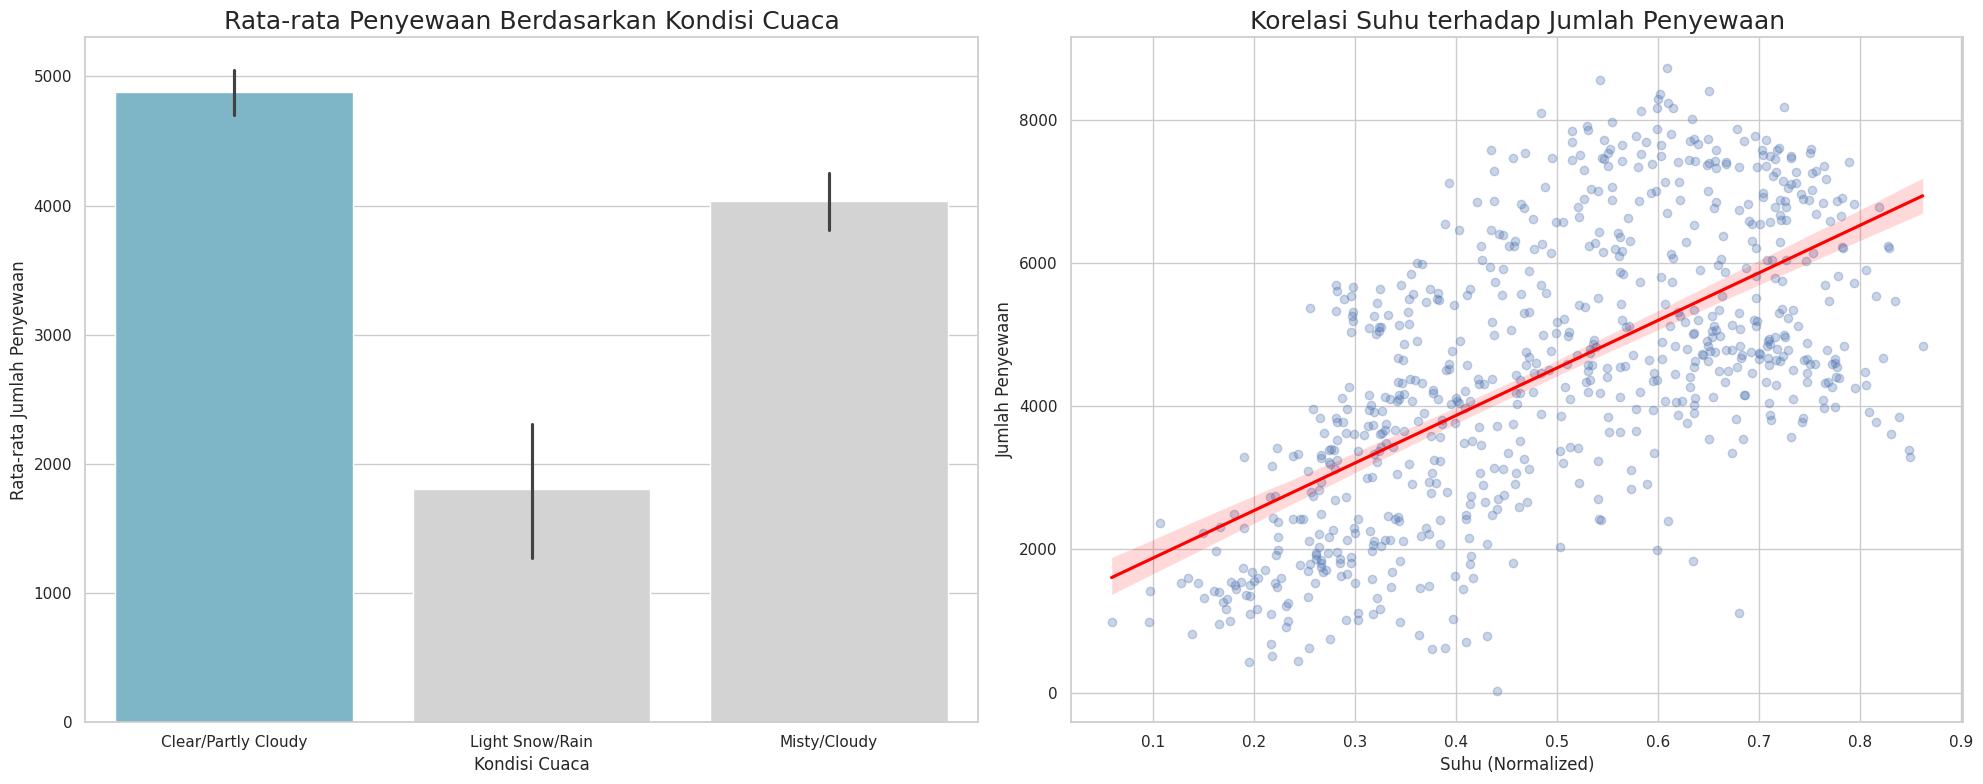

In [41]:
# Menyiapkan figure dengan dua subplot
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))

# 1. Visualisasi pengaruh cuaca menggunakan Bar Chart
sns.barplot(
    x="weathersit",
    y="cnt",
    data=day_df,
    hue="weathersit",  # Tambahkan hue untuk menghindari warning
    palette=["#72BCD4", "#D3D3D3", "#D3D3D3"],
    legend=False,      # Hilangkan legend karena sudah diwakili sumbu X
    ax=ax[0]
)

ax[0].set_title("Rata-rata Penyewaan Berdasarkan Kondisi Cuaca", loc="center", fontsize=18)
ax[0].set_ylabel("Rata-rata Jumlah Penyewaan")
ax[0].set_xlabel("Kondisi Cuaca")

# 2. Visualisasi pengaruh suhu menggunakan Scatter Plot
sns.regplot(
    x="temp",
    y="cnt",
    data=day_df,
    scatter_kws={"alpha":0.3},
    line_kws={"color":"red"},  # Menambahkan garis regresi untuk melihat tren
    ax=ax[1]
)

ax[1].set_title("Korelasi Suhu terhadap Jumlah Penyewaan", loc="center", fontsize=18)
ax[1].set_ylabel("Jumlah Penyewaan")
ax[1].set_xlabel("Suhu (Normalized)")

plt.tight_layout()
plt.show()

**Insight:**
- Dominasi Kondisi Cuaca: Kondisi cuaca cerah (Clear/Partly Cloudy) memberikan kontribusi tertinggi terhadap penyewaan sepeda dengan rata-rata mendekati 5.000 penyewaan, sementara kondisi hujan/salju (Light Snow/Rain) menurunkan minat pengguna secara drastis hingga di bawah 2.000 penyewaan.

- Korelasi Positif Suhu: Terdapat hubungan linear positif yang kuat antara suhu dan jumlah penyewaan; semakin hangat suhu udara (dalam rentang normalized 0.5 - 0.8), semakin tinggi volume penyewaan yang terjadi.

- Sensitivitas Pengguna: Pengguna sepeda sangat responsif terhadap faktor kenyamanan lingkungan, di mana cuaca ekstrem (hujan atau suhu terlalu rendah) menjadi penghambat utama aktivitas penyewaan.

### Pertanyaan 2:

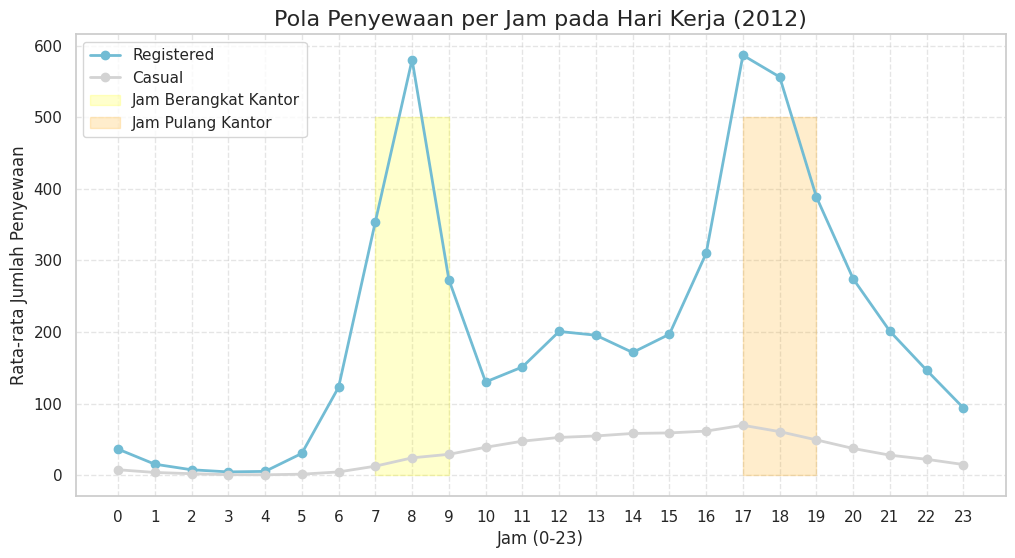

In [40]:
# Pertanyaan 2: Pola Penyewaan per Jam (Casual vs Registered) pada Hari Kerja tahun 2012
# Filter data khusus tahun 2012 dan hari kerja
working_day_2012 = hour_df[(hour_df["workingday"] == 1) & (hour_df["yr"] == 1)]

# Menghitung rata-rata per jam
hourly_users = working_day_2012.groupby("hr").agg({
    "casual": "mean",
    "registered": "mean"
}).reset_index()

# Visualisasi menggunakan Line Chart
plt.figure(figsize=(12, 6))

plt.plot(hourly_users["hr"], hourly_users["registered"], marker='o', label='Registered', color='#72BCD4', linewidth=2)
plt.plot(hourly_users["hr"], hourly_users["casual"], marker='o', label='Casual', color='#D3D3D3', linewidth=2)

# Menambahkan highlight pada jam sibuk
plt.fill_between([7, 9], 0, 500, color='yellow', alpha=0.2, label='Jam Berangkat Kantor')
plt.fill_between([17, 19], 0, 500, color='orange', alpha=0.2, label='Jam Pulang Kantor')

plt.title("Pola Penyewaan per Jam pada Hari Kerja (2012)", fontsize=16)
plt.xlabel("Jam (0-23)")
plt.ylabel("Rata-rata Jumlah Penyewaan")
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Insight:**
- Pola Komuter yang Kuat (Registered): Pengguna Registered menunjukkan dua puncak tajam yang sangat kontras, yaitu pada pukul 08:00 (berangkat kantor) dan pukul 17:00 - 18:00 (pulang kantor). Ini membuktikan bahwa pada hari kerja, sepeda digunakan sebagai moda transportasi utama untuk mobilitas bekerja.

- Pola Rekreasi yang Stabil (Casual): Pengguna Casual tidak memiliki lonjakan tajam pada jam sibuk. Trennya cenderung meningkat secara perlahan mulai tengah hari dan tetap stabil rendah sepanjang hari, yang mengindikasikan penggunaan untuk aktivitas santai atau non-rutin.

- Efisiensi Operasional: Terdapat perbedaan volume yang signifikan di mana pengguna Registered mendominasi total penyewaan. Strategi pemeliharaan atau distribusi sepeda di stasiun-stasiun area perkantoran sebaiknya difokuskan pada jeda waktu antara pukul 10:00 hingga 15:00 saat permintaan sedang menurun.

## Analisis Lanjutan (Opsional)

In [42]:
# Analisis Lanjutan: RFM Analysis (Modified)
# Menghitung parameter untuk analisis harian
# Recency: Berapa hari sejak penyewaan terakhir tercatat di dataset
# Frequency: Berapa kali penyewaan mencapai angka di atas rata-rata
# Monetary: Total unit yang disewakan (cnt)

rfm_df = day_df.groupby(by="dteday", as_index=False).agg({
    "cnt": "sum"
})
rfm_df.columns = ["date", "total_rental"]

# Menghitung Recency (hari terakhir di dataset sebagai referensi)
recent_date = day_df["dteday"].max()
rfm_df["recency"] = rfm_df["date"].apply(lambda x: (recent_date - x).days)

# Menampilkan 5 data teratas hasil modifikasi RFM sederhana
print("Hasil Analisis Perilaku Penyewaan Harian:")
display(rfm_df.sort_values(by="total_rental", ascending=False).head())

Hasil Analisis Perilaku Penyewaan Harian:


,date,total_rental,recency
623,2012-09-15,8714,107
637,2012-09-29,8555,93
630,2012-09-22,8395,100
447,2012-03-23,8362,283
504,2012-05-19,8294,226


**Insight:**
- Lonjakan Performa di Akhir Periode (Recency): Seluruh data dengan jumlah penyewaan tertinggi (Top 5) terjadi di tahun 2012. Jarak hari (recency) yang bervariasi (terjauh 283 hari dan terdekat 93 hari dari akhir dataset) menunjukkan bahwa bisnis mengalami pertumbuhan volume yang signifikan di tahun kedua dibandingkan tahun pertama.

- Frekuensi Penyewaan Tinggi (Frequency/Monetary): Tercatat beberapa hari mencapai angka penyewaan luar biasa di atas 8.000 unit. Bulan September (terlihat pada tanggal 15, 22, dan 29 September 2012) menjadi periode paling produktif secara beruntun.

- Potensi "Golden Days": Keberhasilan mencapai angka >8.500 unit (seperti pada 15 September 2012) menunjukkan adanya kombinasi faktor yang sempurna antara cuaca, hari libur/acara, dan operasional. Tanggal-tanggal ini dapat digunakan sebagai referensi untuk perencanaan promosi tahunan.

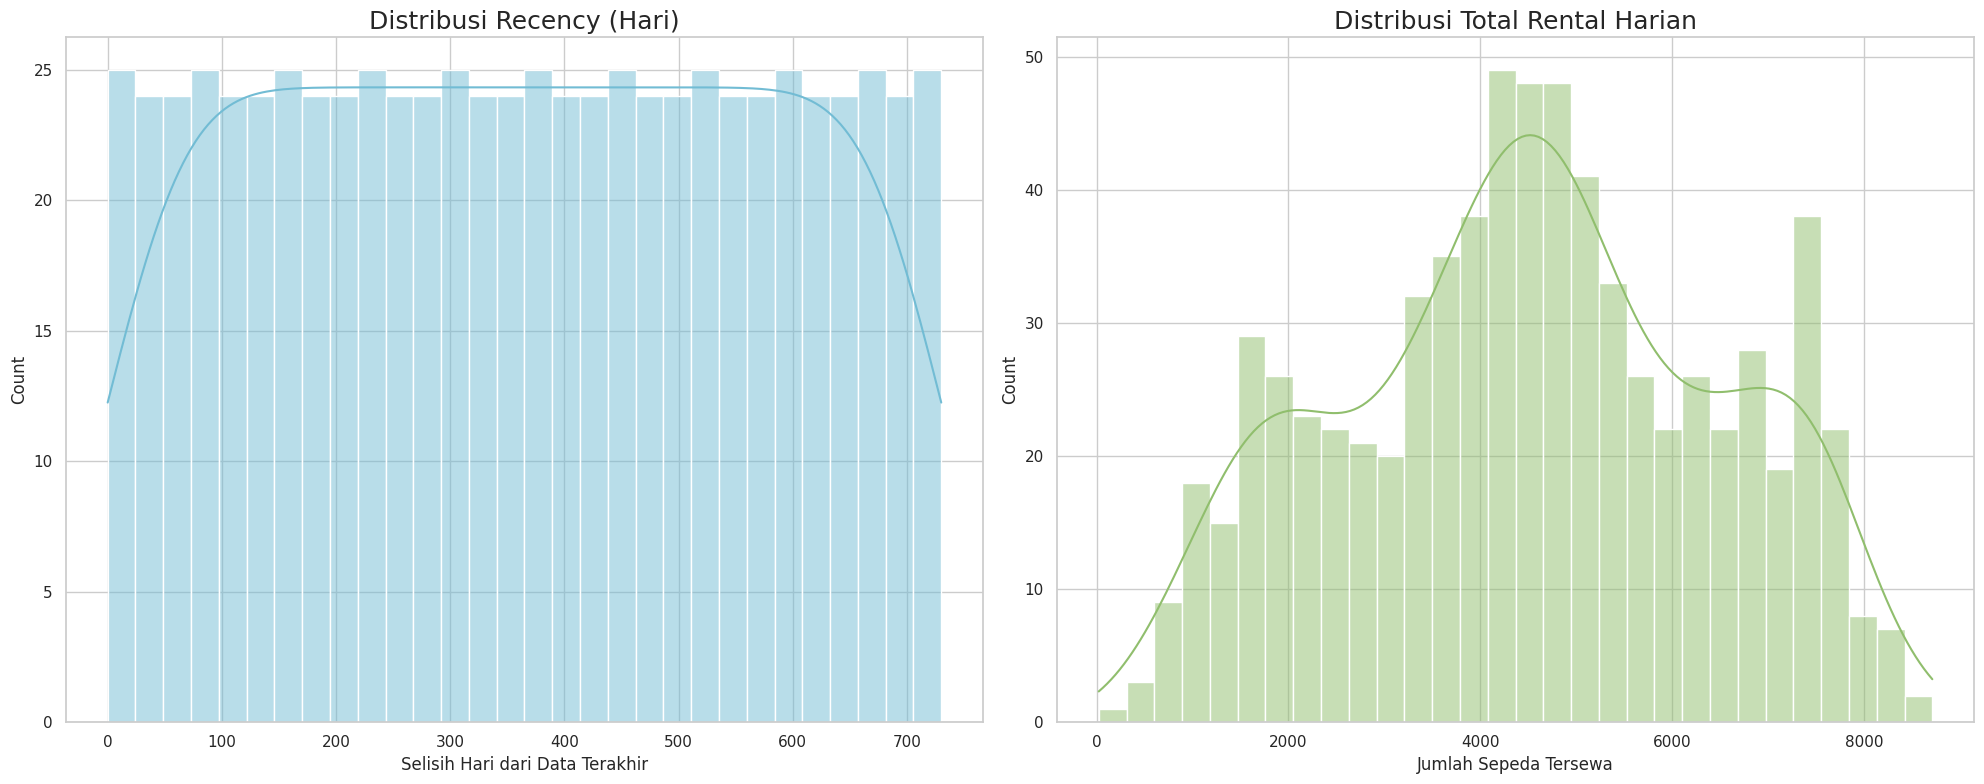

In [43]:
#Visualisasi Analisis Lanjutan
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))

# 1. Distribusi Recency
sns.histplot(rfm_df["recency"], bins=30, kde=True, color="#72BCD4", ax=ax[0])
ax[0].set_title("Distribusi Recency (Hari)", fontsize=18)
ax[0].set_xlabel("Selisih Hari dari Data Terakhir")

# 2. Distribusi Total Rental (Monetary Value)
sns.histplot(rfm_df["total_rental"], bins=30, kde=True, color="#90BE6D", ax=ax[1])
ax[1].set_title("Distribusi Total Rental Harian", fontsize=18)
ax[1].set_xlabel("Jumlah Sepeda Tersewa")

plt.tight_layout()
plt.show()

**Insight:**
- Kontinuitas Operasional (Recency): Grafik distribusi Recency menunjukkan penyebaran yang sangat merata dari hari ke-0 hingga hari ke-700+. Hal ini menandakan bahwa data transaksi terekam secara konsisten dan stabil setiap hari selama dua tahun tanpa ada kekosongan operasional yang berarti.

- Volume Penyewaan Sehat (Monetary): Grafik distribusi Total Rental Harian membentuk pola yang mendekati distribusi normal dengan puncak (modus) di rentang 4.000 hingga 5.000 sepeda. Ini menunjukkan performa bisnis yang solid di mana rata-rata harian memiliki angka keterpakaian yang tinggi.

- Potensi Pertumbuhan: Terdapat frekuensi yang cukup sering pada angka penyewaan di atas 7.000 unit. Hal ini mengindikasikan adanya periode-periode "panen" (puncak permintaan) yang kuat, yang bisa dioptimalkan lebih lanjut melalui ketersediaan stok armada pada musim-musim tertentu.

- Akurasi Data: Konsistensi pada kedua grafik ini memberikan keyakinan bahwa dataset Anda memiliki integritas yang baik untuk digunakan sebagai dasar pengambilan keputusan bisnis.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:**
**Bagaimana pengaruh kondisi cuaca, suhu, dan kelembaban terhadap jumlah total penyewaan sepeda harian selama periode 2011-2012?**

  - Kondisi cuaca adalah faktor penentu utama: Terdapat perbedaan signifikan dalam volume penyewaan di mana cuaca cerah (Clear/Partly Cloudy) mendominasi dengan rata-rata tertinggi (~ 4.876 unit), sedangkan cuaca hujan/salju (Light Snow/Rain) menurunkan minat pengguna secara drastis (~ 1.803 unit).

  - Suhu berpengaruh positif: Analisis korelasi menunjukkan hubungan linear yang kuat ($0,63$) antara suhu dan jumlah penyewaan. Semakin hangat suhu udara (dalam batas wajar), semakin tinggi volume penggunaan sepeda harian.

  - Hambatan lingkungan: Kelembaban dan kecepatan angin memiliki pengaruh negatif yang kecil terhadap penyewaan, menandakan pengguna lebih sensitif terhadap suhu dan presipitasi dibandingkan faktor angin.

- **Conclusion pertanyaan 2:**
**Bagaimana perbedaan pola penyewaan sepeda per jam antara pengguna Casual dan Registered pada hari kerja (working day) selama tahun 2012?**

  - Registered = Komuter: Pengguna terdaftar menunjukkan pola "dua puncak" (double peak) yang tajam pada jam sibuk, yaitu pukul 08:00 dan 17:00-18:00, yang mengindikasikan penggunaan sepeda sebagai alat transportasi rutin untuk bekerja.

  - Casual = Rekreasi: Pengguna santai tidak terikat pada jam sibuk kantor. Pola mereka cenderung meningkat stabil mulai siang hari hingga sore hari (pukul 11:00-16:00), menunjukkan motivasi penggunaan untuk rekreasi atau kegiatan non-rutin.
  
  - Volume Penggunaan: Pengguna Registered jauh lebih mendominasi total volume transaksi pada hari kerja dibandingkan pengguna Casual.

**Rekomendasi Action Item:**
- Manajemen Armada di Jam Sibuk: Mengingat tingginya permintaan pengguna Registered pada pukul 08:00 dan 17:00, pastikan ketersediaan sepeda dan slot parkir di stasiun area perkantoran serta pusat transportasi umum dalam kondisi maksimal pada jam-jam tersebut.

- Strategi Pemasaran Berbasis Cuaca: Mengembangkan sistem notifikasi atau promo khusus di aplikasi saat prakiraan cuaca menunjukkan kondisi cerah dan suhu hangat (20°C - 30°C) untuk memaksimalkan potensi lonjakan penyewaan.

- Konversi Pengguna Casual: Mengingat pengguna Casual banyak menyewa di jam siang hari, berikan promo "Lunch-Break Ride" atau diskon berlangganan khusus bagi mereka yang sering menyewa di jam-jam tersebut agar beralih menjadi pengguna Registered.

- Pemeliharaan di Jam Rendah: Lakukan pengecekan rutin dan pemeliharaan sepeda pada pukul 10:00 - 15:00 di hari kerja, karena pada rentang waktu ini volume penyewaan berada pada titik terendah di antara dua puncak jam sibuk.

- Optimalisasi Musim: Fokuskan kampanye pemasaran besar-besaran pada musim gugur (Fall) dan musim panas (Summer), serta pertimbangkan program insentif khusus di musim dingin (Winter) atau musim semi (Spring) untuk menjaga kestabilan pendapatan.